In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples, silhouette_score

#### Ruta donde se encuentra el dataset

In [14]:
ruta= ''

In [15]:
df = pd.read_csv(ruta+'proveedores2016_2022_nuevas_var_disc_ipc.csv', sep='|')

In [16]:
df

,Unnamed: 0,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,...,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA,total_articulos_provee,dmonto_total_adjudicado,dcant_procesos_adjudicado,dtotal_articulos_provee
0,0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,0.0,0.0,0.0,0.0,0.0,0.0,68.0,"(9424898.401, 13557176.81]","(39.0, 1214.0]","(58.0, 97.6]"
1,1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,0.0,0.0,0.0,0.0,0.0,0.0,330.0,"(4727330.113, 6702697.888]","(6.0, 8.0]","(161.0, 345.0]"
2,2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...",...,0.0,0.0,0.0,1.0,0.0,0.0,105.0,"(6702697.888, 9424898.401]","(19.0, 39.0]","(97.6, 161.0]"
3,3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...",...,0.0,0.0,0.0,0.0,0.0,0.0,83.0,"(46718747.516, 89439449.702]","(39.0, 1214.0]","(58.0, 97.6]"
4,4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...",...,0.0,0.0,0.0,0.0,0.0,0.0,38.0,"(4727330.113, 6702697.888]","(0.999, 2.0]","(29.0, 40.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...",...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,"(4727330.113, 6702697.888]","(0.999, 2.0]","(0.999, 2.0]"
10072,10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...",...,0.0,0.0,0.0,0.0,0.0,0.0,6.0,"(13557176.81, 19975532.58]","(0.999, 2.0]","(4.0, 6.0]"
10073,10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"(9424898.401, 13557176.81]","(0.999, 2.0]","(0.999, 2.0]"
10074,10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,"(104767.373, 224078.198]","(0.999, 2.0]","(15.0, 21.0]"


### Preparación de los datos

In [17]:
#elimina campo Unnamed: 0
df.drop('Unnamed: 0', inplace=True, axis=1)

In [6]:
# Crear el perfil con configuración mínima
profile = ProfileReport(df, minimal=True, title="Perfil de Datos (Minimal)", explorative=True)
profile.to_file(ruta+"reporte_minimal.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/83 [00:00<?, ?it/s]
%|██                                                                                 | 2/83 [00:00<00:17,  4.72it/s]
%|█████                                                                              | 5/83 [00:00<00:11,  6.58it/s]
%|███████████████▊                                                                  | 16/83 [00:00<00:02, 23.40it/s]
%|████████████████████████████████████████████▍                                     | 45/83 [00:01<00:00, 72.26it/s]
%|███████████████████████████████████████████████████████████▎                      | 60/83 [00:01<00:00, 87.57it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 83/83 [00:01<00:00, 63.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Se realiza la imputación de los numéricos

In [18]:
#En este caso se imputa el valor nulo con 0 porque se interpreta el nulo como que no tiene procesos adjudicados.
df['cant_procesos_adjudicado'] = df['cant_procesos_adjudicado'].fillna(0)
#Se imputa nulo con cero porque al no tener proceso adjudicado tampoco monto asociado a ese proceso
df['monto_total_adjudicado'] = df['monto_total_adjudicado'].fillna(0)
#Se imputa nulo con -1 para resaltar el hecho de que ese dato no esta completo dado que cero indica que ingresó en 2022.
df['antiguedad'] = df['antiguedad'].fillna(-1)
#Se imputa nulo con cero porque indica que no tiene socios
df['cant_socios'] = df['cant_socios'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene apercibimientos
df['cant_apercibimientos'] = df['cant_apercibimientos'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene suspensiones
df['cant_suspensiones'] = df['cant_suspensiones'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene antecedentes
df['cant_antecedentes'] = df['cant_antecedentes'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene antecedentes
df['cant_antecedentes'] = df['cant_antecedentes'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene apoderado
df['cant_Apoderado'] = df['cant_Apoderado'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representante
df['cant_representante'] = df['cant_representante'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes autenticados
df['cant_autenticado'] = df['cant_autenticado'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes no autenticados
df['cant_noAutenticado'] = df['cant_noAutenticado'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes sin monto límite para operar
df['cant_sinMontoLimite'] = df['cant_sinMontoLimite'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes con monto límite para operar
df['cant_MontoLimite'] = df['cant_MontoLimite'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes con monto límite para operar
df['cant_MontoLimite'] = df['cant_MontoLimite'].fillna(0)
#Se imputa nulo con -1 porque resaltar que no se tiene el dato de los rubros que provee
df['TOT_AGROPECUARIO'] = df['TOT_AGROPECUARIO'].fillna(-1)
df['TOT_ALIMENTOS'] = df['TOT_ALIMENTOS'].fillna(-1)
df['TOT_ALQUILER'] = df['TOT_ALQUILER'].fillna(-1)
df['TOT_ART_HOGAR'] = df['TOT_ART_HOGAR'].fillna(-1)
df['TOT_BANCO'] = df['TOT_BANCO'].fillna(-1)
df['TOT_BAZAR'] = df['TOT_BAZAR'].fillna(-1)
df['TOT_CARPINTERIA'] = df['TOT_CARPINTERIA'].fillna(-1)
df['TOT_CEREMONIAL'] = df['TOT_CARPINTERIA'].fillna(-1)
df['TOT_CEREMONIAL'] = df['TOT_CEREMONIAL'].fillna(-1)
df['TOT_CERRAJERIA'] = df['TOT_CERRAJERIA'].fillna(-1)
df['TOT_CINE'] = df['TOT_CINE'].fillna(-1)
df['TOT_COMBUSTIBLES'] = df['TOT_COMBUSTIBLES'].fillna(-1)
df['TOT_CONCESION'] = df['TOT_CONCESION'].fillna(-1)
df['TOT_CONSTRUCCION'] = df['TOT_CONSTRUCCION'].fillna(-1)
df['TOT_CULTURA'] = df['TOT_CULTURA'].fillna(-1)
df['TOT_ELECTRICIDAD'] = df['TOT_ELECTRICIDAD'].fillna(-1)
df['TOT_LIMPIEZA'] = df['TOT_LIMPIEZA'].fillna(-1)
df['TOT_MUEBLES'] = df['TOT_MUEBLES'].fillna(-1)
df['TOT_EQUIPO_MILITAR'] = df['TOT_EQUIPO_MILITAR'].fillna(-1)
df['TOT_EQUIPOS'] = df['TOT_EQUIPOS'].fillna(-1)
df['TOT_FERRETERIA'] = df['TOT_FERRETERIA'].fillna(-1)
df['TOT_GASES_IND'] = df['TOT_GASES_IND'].fillna(-1)
df['TOT_HERRAMIENTAS'] = df['TOT_HERRAMIENTAS'].fillna(-1)
df['TOT_HERRERIA'] = df['TOT_HERRERIA'].fillna(-1)
df['TOT_IMPRENTA'] = df['TOT_IMPRENTA'].fillna(-1)
df['TOT_INDUMENTARIA'] = df['TOT_INDUMENTARIA'].fillna(-1)
df['TOT_INFORMATICA'] = df['TOT_INFORMATICA'].fillna(-1)
df['TOT_INMUEBLES'] = df['TOT_INMUEBLES'].fillna(-1)
df['TOT_INSUMO_ARMAMENTO'] = df['TOT_INSUMO_ARMAMENTO'].fillna(-1)
df['TOT_JOYERIA'] = df['TOT_JOYERIA'].fillna(-1)
df['TOT_LIBRERIA'] = df['TOT_LIBRERIA'].fillna(-1)
df['TOT_MANTENIMIENTO'] = df['TOT_MANTENIMIENTO'].fillna(-1)
df['TOT_METALES'] = df['TOT_METALES'].fillna(-1)
df['TOT_METALURGIA'] = df['TOT_METALURGIA'].fillna(-1)
df['TOT_NAUTICA'] = df['TOT_NAUTICA'].fillna(-1)
df['TOT_PINTURAS'] = df['TOT_PINTURAS'].fillna(-1)
df['TOT_PROD_MEDICOS'] = df['TOT_PROD_MEDICOS'].fillna(-1)
df['TOT_PROD_VETERINARIOS'] = df['TOT_PROD_VETERINARIOS'].fillna(-1)
df['TOT_QUIMICOS'] = df['TOT_QUIMICOS'].fillna(-1)
df['TOT_REPUESTOS'] = df['TOT_REPUESTOS'].fillna(-1)
df['TOT_PLOMERIA'] = df['TOT_PLOMERIA'].fillna(-1)
df['TOT_SERV_PROFESIONAL'] = df['TOT_SERV_PROFESIONAL'].fillna(-1)
df['TOT_SERV_NOTICIAS'] = df['TOT_SERV_NOTICIAS'].fillna(-1)
df['TOT_SERV_BASICOS'] = df['TOT_SERV_BASICOS'].fillna(-1)
df['TOT_TAPICERIA'] = df['TOT_TAPICERIA'].fillna(-1)
df['TOT_TRANSPORTE'] = df['TOT_TRANSPORTE'].fillna(-1)
df['TOT_PROD_DEPORTIVOS'] = df['TOT_PROD_DEPORTIVOS'].fillna(-1)
df['TOT_VIDRIERIA'] = df['TOT_VIDRIERIA'].fillna(-1)
df['TOT_VIGILANCIA'] = df['TOT_VIGILANCIA'].fillna(-1)
#se imputa con cero para indicar que no provee ningún artículo
df['total_articulos_provee'] = df['total_articulos_provee'].fillna(0)


### Arma dataset numérico

In [19]:
#armar dataset de valores numéricos
df_num = df[['cant_procesos_adjudicado','monto_total_adjudicado','antiguedad','cant_socios','cant_apercibimientos','cant_suspensiones',
'cant_antecedentes', 'cant_Apoderado', 'cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite',
'TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER','TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA',
'TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION','TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR',
'TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS','TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA',
'TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL',
'TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA','total_articulos_provee']] 
df_num

,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,...,TOT_PLOMERIA,TOT_SERV_PROFESIONAL,TOT_SERV_NOTICIAS,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA,total_articulos_provee
0,68.0,1.069618e+07,5.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0
1,7.0,4.975162e+06,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,330.0
2,22.0,7.425067e+06,5.0,2.0,1.0,2.0,4.0,2.0,1.0,2.0,...,63.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,105.0
3,111.0,5.959313e+07,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0
4,1.0,5.434774e+06,5.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,1.0,5.792102e+06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
10072,1.0,1.757476e+07,0.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
10073,1.0,1.119596e+07,0.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10074,1.0,1.196939e+05,2.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0


### Dataset numérico reducido (sin las variables de total por rubro)

In [20]:
#armar dataset de valores numéricos
df_num_red = df[['cant_procesos_adjudicado','monto_total_adjudicado','antiguedad','cant_socios','cant_apercibimientos','cant_suspensiones',
'cant_antecedentes', 'cant_Apoderado', 'cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite',
'total_articulos_provee']] 
df_num_red

,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,cant_noAutenticado,cant_sinMontoLimite,cant_MontoLimite,total_articulos_provee
0,68.0,1.069618e+07,5.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,68.0
1,7.0,4.975162e+06,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,330.0
2,22.0,7.425067e+06,5.0,2.0,1.0,2.0,4.0,2.0,1.0,2.0,1.0,3.0,0.0,105.0
3,111.0,5.959313e+07,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,83.0
4,1.0,5.434774e+06,5.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,1.0,5.792102e+06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
10072,1.0,1.757476e+07,0.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,6.0
10073,1.0,1.119596e+07,0.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
10074,1.0,1.196939e+05,2.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,19.0


# Realiza limpieza de datos

### Verifica si hay duplicados

In [8]:
#Realiza limpieza de datos: elimina duplicados, trata valores nulos y corrige inconsistencias.
duplicados = df.duplicated()
print("Número de filas duplicadas:", duplicados.sum())

Número de filas duplicadas: 0


### Tratamiento de valores nulos

In [11]:
#ver el % de nulos por variables
total_filas = len(df)

# Calcular cantidad y porcentaje de nulos por variable
nulos_por_variable = df_num.isnull().sum().reset_index()
nulos_por_variable.columns = ['Variable', 'Cantidad de Nulos']
nulos_por_variable['Porcentaje de Nulos (%)'] = (nulos_por_variable['Cantidad de Nulos'] / total_filas) * 100

#pd.set_option('display.max_rows', None)
# Mostrar la tabla
nulos_por_variable

,Variable,Cantidad de Nulos,Porcentaje de Nulos (%)
0,cant_procesos_adjudicado,0,0.0
1,monto_total_adjudicado,0,0.0
2,antiguedad,0,0.0
3,cant_socios,0,0.0
4,cant_apercibimientos,0,0.0
...,...,...,...
57,TOT_TRANSPORTE,0,0.0
58,TOT_PROD_DEPORTIVOS,0,0.0
59,TOT_VIDRIERIA,0,0.0
60,TOT_VIGILANCIA,0,0.0


In [12]:
# Función para calcular los estadísticos
def calcular_estadisticos(df):
    estadisticas = pd.DataFrame()
    for col in df.columns:
        stats = {
            'count': df[col].count(),
            'nulos': df[col].isnull().sum(),
            'ceros': (df[col] == 0).sum(),
            'media': df[col].mean(),
            'mediana': df[col].median(),
            'moda': df[col].mode()[0] if not df[col].mode().empty else None,
            'desvio_std': df[col].std(),
            'min': df[col].min(),
            'max': df[col].max(),
            'varianza': df[col].var(),
            'rango': df[col].max() - df[col].min(),
        }
        # Agregar percentiles
        percentiles = df[col].quantile([i/100 for i in range(0, 101, 5)]).to_dict()
        stats.update({f'percentil_{int(p*100)}': v for p, v in percentiles.items()})
        
        #agregar percentil 99

        estadisticas = pd.concat([estadisticas, pd.DataFrame(stats, index=[col])])
    
    return estadisticas

In [13]:
# Calcular estadísticas
resultado = calcular_estadisticos(df_num)

# Mostrar resultados
#pd.set_option('display.max_rows', None)  # Muestra todas las filas
#pd.set_option('display.max_columns', None)  # Muestra todas las columnas
print(resultado)

# Exportar a CSV si se desea
resultado.to_csv('estadisticas_dataset_num.csv', sep='|', encoding='utf-8-sig', decimal=',')


                          count  nulos  ceros         media      mediana  \
cant_procesos_adjudicado  10076      0     51  1.069839e+01        2.000   
monto_total_adjudicado    10076      0    134  7.484517e+07  3345286.726   
antiguedad                10076      0   1229  3.003573e+00        4.000   
cant_socios               10076      0   3970  1.274514e+00        1.000   
cant_apercibimientos      10076      0   9935  1.508535e-02        0.000   
...                         ...    ...    ...           ...          ...   
TOT_TRANSPORTE            10076      0   9510  1.035133e-01        0.000   
TOT_PROD_DEPORTIVOS       10076      0   9861  9.567289e-02        0.000   
TOT_VIDRIERIA             10076      0   9881  2.084160e-02        0.000   
TOT_VIGILANCIA            10076      0   9564  2.816594e-01        0.000   
total_articulos_provee    10076      0     99  6.944135e+01        8.000   

                          moda    desvio_std  min           max      varianza  \
cant_p

In [14]:
# Mostrar los nombres de las columnas que tienen valores nulos
print(df_num.columns[df_num.isnull().any()])

Index([], dtype='object')


In [50]:
df_num_red

,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,cant_noAutenticado,cant_sinMontoLimite,cant_MontoLimite,total_articulos_provee
0,68.0,1.069618e+07,5.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,68.0
1,7.0,4.975162e+06,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,330.0
2,22.0,7.425067e+06,5.0,2.0,1.0,2.0,4.0,2.0,1.0,2.0,1.0,3.0,0.0,105.0
3,111.0,5.959313e+07,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,83.0
4,1.0,5.434774e+06,5.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,1.0,5.792102e+06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
10072,1.0,1.757476e+07,0.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,6.0
10073,1.0,1.119596e+07,0.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
10074,1.0,1.196939e+05,2.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,19.0


### Escalado de los datos:



In [21]:
##Normaliza o estandariza los datos para que todas las variables tengan la misma importancia, especialmente si utilizan escalas diferentes.
scaler = StandardScaler()
df_normalizado = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)
df_num_red_normalizado = pd.DataFrame(scaler.fit_transform(df_num_red), columns=df_num_red.columns)


In [22]:
df_num_red_normalizado

,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,cant_noAutenticado,cant_sinMontoLimite,cant_MontoLimite,total_articulos_provee
0,1.345427,-0.095352,1.225788,-0.819175,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,-0.005958
1,-0.086837,-0.103856,1.225788,-0.176440,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,1.077125
2,0.265359,-0.100214,1.225788,0.466295,7.501256,8.681731,12.814532,1.406325,0.931322,1.510918,1.563411,2.167353,-0.114325,0.146996
3,2.355055,-0.022671,1.225788,-0.176440,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,0.056050
4,-0.227716,-0.103172,1.225788,0.466295,-0.114892,-0.092303,-0.125859,-1.157940,0.931322,-0.341377,-0.294027,-0.416749,-0.114325,-0.129976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,-0.227716,-0.102641,-1.844166,-0.819175,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,-0.282930
10072,-0.227716,-0.085127,-1.844166,0.466295,-0.114892,-0.092303,-0.125859,0.124192,0.931322,-0.341377,1.563411,0.875302,-0.114325,-0.262261
10073,-0.227716,-0.094609,-1.844166,1.109031,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-1.708800,5.560261,-0.282930
10074,-0.227716,-0.111073,-0.616185,0.466295,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,-0.208520


In [18]:
# Exportar a CSV 
df_normalizado.to_csv(ruta+'df_cluster.csv', sep='|', encoding='utf-8-sig', decimal=',')


In [19]:
# Exportar a CSV 
df_num.to_csv(ruta+'df_num.csv', sep='|', encoding='utf-8', decimal=',')

## K-means

### Obtener el  número de grupos

### Silhouette

In [1]:
#Se evaluan distintos valores de K para K-Means con el objrtivo de ver qué tan buenos son los clusters usando el Silhouette Score.


In [23]:
# Definir el rango de K a probar
rango_k = range(2, 21)  # Probar desde 2 hasta 20

# Lista para guardar los puntajes
silhouette_scores = []
cluster_counts = {}

# Crear una copia del DataFrame normalizado para agregar los clusters

df_cluster = df_num_red_normalizado.copy()
# Calcular Silhouette Score para cada K
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(df_num_red_normalizado)
    score = silhouette_score(df_num_red_normalizado, etiquetas)
    silhouette_scores.append(score)

    # Agregar la columna del clúster al DataFrame
    df_cluster[f'cluster_k{k}'] = etiquetas
    #agrega el cluster al dataset original
    df[f'cluster_k{k}'] = etiquetas
    
    # Contar los clusters
    cluster_counts[k] = df_cluster[f'cluster_k{k}'].value_counts().to_dict()
    
    print(f"K={k}, Silhouette Score={score:.4f}")
    print(df_cluster[f'cluster_k{k}'].value_counts())
   
# Crear la tabla de resultados
resultados = []
for k, clusters in cluster_counts.items():
    for cluster, count in clusters.items():
        resultados.append({'K': k, 'Cluster': cluster, 'Count': count, 'Silhouette Score': silhouette_scores[k - 2]})

# Convertir a DataFrame
tabla_resultados = pd.DataFrame(resultados)

# Mostrar la tabla de puntajes
resultado_silhouette = pd.DataFrame({'K': rango_k, 'Silhouette Score': silhouette_scores})
print(resultado_silhouette)

# Mostrar la tabla final
tabla_resultados = tabla_resultados.sort_values(['K', 'Cluster']).reset_index(drop=True)
print(tabla_resultados)


K=2, Silhouette Score=0.7265
cluster_k2
0    9876
1     200
Name: count, dtype: int64
K=3, Silhouette Score=0.3537
cluster_k3
0    7403
1    2474
2     199
Name: count, dtype: int64
K=4, Silhouette Score=0.2798
cluster_k4
0    5213
2    3005
1    1660
3     198
Name: count, dtype: int64
K=5, Silhouette Score=0.2887
cluster_k5
1    5692
3    3540
0     571
2     153
4     120
Name: count, dtype: int64
K=6, Silhouette Score=0.2941
cluster_k6
0    5676
4    3499
1     548
2     197
5     150
3       6
Name: count, dtype: int64
K=7, Silhouette Score=0.3048
cluster_k7
3    5154
4    2928
0    1605
1     151
5     112
6      64
2      62
Name: count, dtype: int64
K=8, Silhouette Score=0.2637
cluster_k8
1    3723
7    3236
0    2148
4     411
2     220
5     149
6     124
3      65
Name: count, dtype: int64
K=9, Silhouette Score=0.2720
cluster_k9
1    3711
7    3217
0    2148
4     390
2     226
5     148
6     110
3      64
8      62
Name: count, dtype: int64
K=10, Silhouette Score=0.2729
cl

#### Gráfico de silhouette


Silhouette promedio: 0.2729


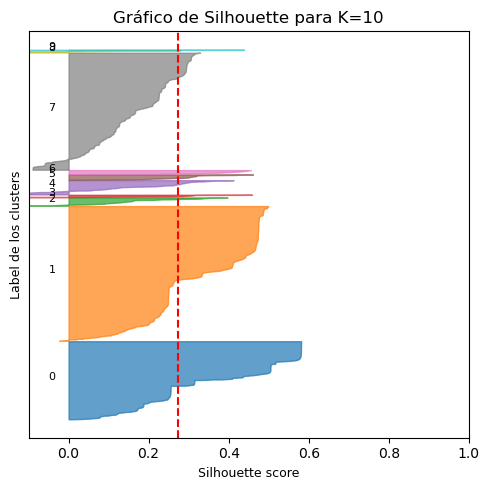

In [16]:
# Ejecuta K-Means con n clusters y genera el gráfico de Silhouette
# para evaluar la calidad y separación de los clusters.

# Número de clusters
n = 10

# Ajustar KMeans
kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_num_red_normalizado)

# Silhouette values y promedio
silhouette_vals = silhouette_samples(df_num_red_normalizado, cluster_labels)
avg_silhouette = silhouette_score(df_num_red_normalizado, cluster_labels)

print(f"Silhouette promedio: {avg_silhouette:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
y_lower = 10

for i in range(n):
    ith_cluster_vals = silhouette_vals[cluster_labels == i]
    ith_cluster_vals.sort()
    
    size_cluster_i = ith_cluster_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.tab10(i / n)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10

# Línea promedio
ax.axvline(x=avg_silhouette, color="red", linestyle="--")

# Estética
ax.set_title(f"Gráfico de Silhouette para K={n}", fontsize=12)
ax.set_xlabel("Silhouette score", fontsize=9)
ax.set_ylabel("Label de los clusters", fontsize=9)
ax.set_yticks([])
ax.set_xlim([-0.1, 1])
plt.tight_layout()
plt.show()


K=2, Silhouette Score=0.7265
cluster_k2
0    9876
1     200
Name: count, dtype: int64
K=3, Silhouette Score=0.3537
cluster_k3
0    7403
1    2474
2     199
Name: count, dtype: int64
K=4, Silhouette Score=0.2798
cluster_k4
0    5213
2    3005
1    1660
3     198
Name: count, dtype: int64
K=5, Silhouette Score=0.2887
cluster_k5
1    5692
3    3540
0     571
2     153
4     120
Name: count, dtype: int64
K=6, Silhouette Score=0.2941
cluster_k6
0    5676
4    3499
1     548
2     197
5     150
3       6
Name: count, dtype: int64
K=7, Silhouette Score=0.3048
cluster_k7
3    5154
4    2928
0    1605
1     151
5     112
6      64
2      62
Name: count, dtype: int64
K=8, Silhouette Score=0.2637
cluster_k8
1    3723
7    3236
0    2148
4     411
2     220
5     149
6     124
3      65
Name: count, dtype: int64
K=9, Silhouette Score=0.2720
cluster_k9
1    3711
7    3217
0    2148
4     390
2     226
5     148
6     110
3      64
8      62
Name: count, dtype: int64
K=10, Silhouette Score=0.2729
cl

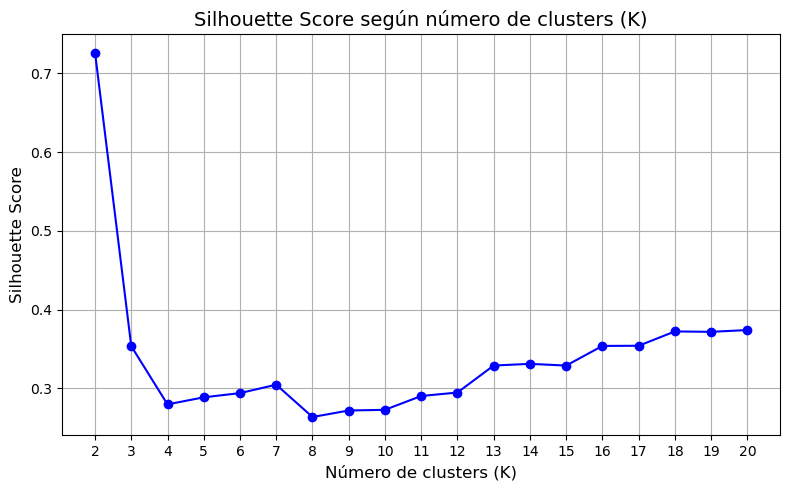

In [62]:
# Prueba K-Means con K de 2 a 20, calcula el Silhouette Score, guarda los clusters
# y grafica el score para identificar el número óptimo de clusters.

rango_k = range(2, 21)
silhouette_scores = []
cluster_counts = {}
df_cluster = df_num_red_normalizado.copy()

# Verificar índices consistentes
assert df.index.equals(df_num_red_normalizado.index), "Los índices de df y df_num_red_normalizado no coinciden"

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(df_num_red_normalizado)
    score = silhouette_score(df_num_red_normalizado, etiquetas)
    silhouette_scores.append(score)
    
    df_cluster[f'cluster_k{k}'] = etiquetas
    df[f'cluster_k{k}'] = etiquetas  # Solo si sabés que es seguro

    cluster_counts[k] = df_cluster[f'cluster_k{k}'].value_counts().to_dict()
    
    print(f"K={k}, Silhouette Score={score:.4f}")
    print(df_cluster[f'cluster_k{k}'].value_counts())

# Resultado y gráfico
resultado_silhouette = pd.DataFrame({'K': list(rango_k), 'Silhouette Score': silhouette_scores})

plt.figure(figsize=(8, 5))
plt.plot(resultado_silhouette['K'], resultado_silhouette['Silhouette Score'], marker='o', color='blue')
plt.title('Silhouette Score según número de clusters (K)', fontsize=14)
plt.xlabel('Número de clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(resultado_silhouette['K'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Tabla de resultados
resultados = []
for idx, k in enumerate(rango_k):
    for cluster, count in cluster_counts[k].items():
        resultados.append({
            'K': k,
            'Cluster': cluster,
            'Count': count,
            'Silhouette Score': silhouette_scores[idx]
        })

tabla_resultados = pd.DataFrame(resultados).sort_values(['K', 'Cluster']).reset_index(drop=True)

#### Guardar los resultados en archivo de texto para analizarlo

In [22]:
tabla_resultados.to_csv(ruta+'resultado_cluster_reducido.csv', sep='|', encoding='utf-8', decimal=',')

In [23]:
df.to_csv(ruta+'df_cluster_kmeans_red.csv', sep='|', encoding='utf-8', decimal=',')

### Elbow

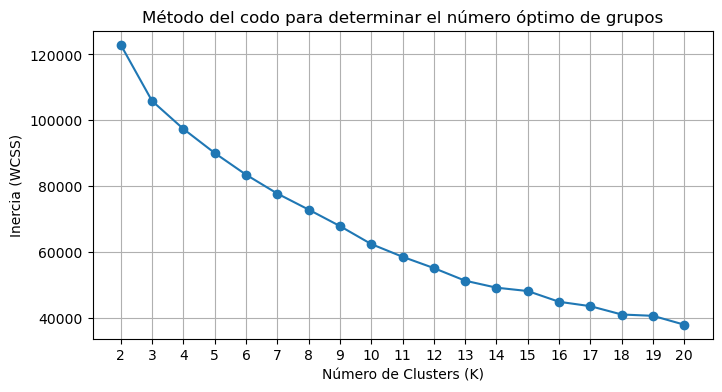

In [12]:
# Rango de valores de K a evaluar (por ejemplo, de 2 a 20)
K_range = range(2, 21)
inertia = []

# Calcular la inercia para cada valor de K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_num_red_normalizado)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del codo para determinar el número óptimo de grupos")
plt.grid(True)

# Mostrar todos los valores de K en el eje X
plt.xticks(list(K_range))

plt.show()

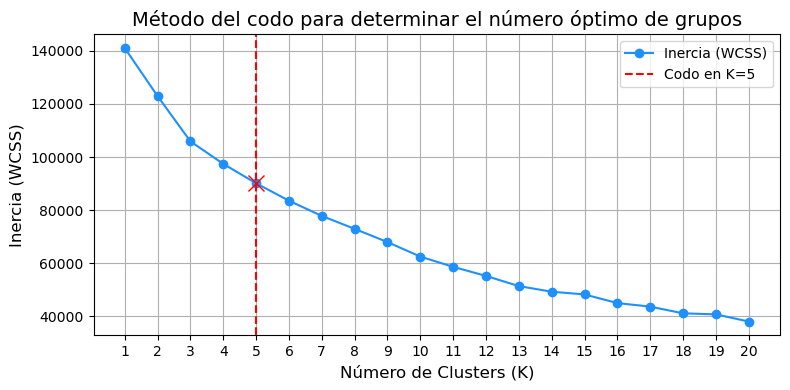

In [13]:
# Calcular la inercia para diferentes valores de K
wcss = []
K_range = range(1, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_num_red_normalizado)
    wcss.append(kmeans.inertia_)

# Elegimos el K óptimo (según se analizó previamente)
optimal_k = 5

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, 'o-', color='dodgerblue', label='Inercia (WCSS)')
plt.axvline(x=optimal_k, linestyle='--', color='red', label=f'Codo en K={optimal_k}')
plt.plot(optimal_k, wcss[optimal_k - 1], 'rx', markersize=12)

# Estética del gráfico
plt.title('Método del codo para determinar el número óptimo de grupos', fontsize=14)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.legend()
# Mostrar todos los valores de K en el eje X
plt.xticks(list(K_range))

plt.grid(True)
plt.tight_layout()
plt.show()


#### Se calcula la segunda derivada para poder saber el posible codo

In [14]:


# 1) Primera derivada (aprox)
diff_inertia = np.diff(inertia)  
# Este array tendrá len=19 si inertia tiene len=20

# 2) Segunda derivada (aprox)
second_diff_inertia = np.diff(diff_inertia)
# Este array tendrá len=18

# 3) Buscar el índice de la segunda derivada más grande (cambio más brusco)
idx_elbow = np.argmax(second_diff_inertia)

# 4) Ajustar el índice al valor de K
# La primera derivada pierde 1 posición respecto a inertia,
# la segunda derivada pierde otra más, en total 2 posiciones.
k_elbow = K_range[idx_elbow + 2]

print("Posible codo en K =", k_elbow)

Posible codo en K = 9


In [15]:
df

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,cluster_k11,cluster_k12,cluster_k13,cluster_k14,cluster_k15,cluster_k16,cluster_k17,cluster_k18,cluster_k19,cluster_k20
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,5,1,0,0,10,1,0,1,0,0
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,5,1,0,0,10,1,0,1,0,0
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,8,7,8,10,12,12,15,14,17,14
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,5,1,0,0,10,1,0,1,0,0
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,3,4,4,3,1,13,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,0,0,2,4,2,0,3,2,3,1
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,2,2,1,5,6,4,6,8,7,3
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,7,8,9,8,9,9,11,10,14,12
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,0,0,2,4,2,0,3,2,3,1


### Se realiza una prueba con Reducción de dimensiones

### PCA

In [27]:
# Estandarizar los datos (esto es importante para PCA)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_num_red)

# Paso 2: Aplicar PCA para reducir la dimensionalidad
pca = PCA(n_components=2)  # Reducir a 2 dimensiones para visualización
pca_result = pca.fit_transform(data_scaled) #

# Paso 3: Visualización de los resultados
# Graficar las dos primeras componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='royalblue', edgecolor='k', alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Reducción de Dimensiones')
plt.grid(True)
plt.show()

# Mostrar la cantidad de varianza explicada por las dos primeras componentes
print(f'Varianza explicada por cada componente: {pca.explained_variance_ratio_}')
print(f'Varianza total explicada: {sum(pca.explained_variance_ratio_)}')

# Mostrar las componentes principales (pesos) para cada variable
print('Componentes principales:')
print(pca.components_)

Varianza explicada por cada componente: [0.20559747 0.17222723]
Varianza total explicada: 0.37782470416435787
Componentes principales:
[[ 0.11776387  0.10523541  0.17506678  0.24158878  0.1239303   0.10993287
   0.14285452  0.39931019  0.20841952  0.40442894  0.40593442  0.54829586
   0.07174407  0.03440763]
 [ 0.28292619  0.02710546  0.07505445 -0.05844564  0.43833583  0.49497407
   0.5891879  -0.12478966 -0.04148123 -0.11365537 -0.1131868  -0.15571429
  -0.00914094  0.24194329]]


C:\Users\27273398320\AppData\Local\Temp\1\ipykernel_11644\358539673.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [2]:
#las dos primeras componentes principales explican solo el 37.8% de la variabilidad de los datos. Por lo que se necesitan más componentes para explicar el 80% de los datos y que tenga sentido aplicar este método

### T-sne

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(df_normalizado) #df_num_red

# Paso 3: Graficar las dos dimensiones resultantes
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=50, alpha=0.7)
plt.title('Visualización de datos reducidos con t-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()

In [ ]:
# Reducimos dimensiones con t-SNE (esto puede tomar tiempo)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df_normalizado)

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10,11,12,13,14,15,16,17,18,19,20]
#k_values = [2]
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_normalizado)
    
    plt.figure(figsize=(7,8))  # un poco más ancho para dar espacio a la leyenda
    cmap = plt.get_cmap('tab10')
    
    for cluster_id in range(k):
        idx = labels == cluster_id
        count = idx.sum()
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                    color=cmap(cluster_id),
                    label=f'Cluster {cluster_id} (n={count})',
                    alpha=0.7,
                    s=50)
    
    plt.title(f'Clusters visualizados con t-SNE para k={k}')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True)

    # Leyenda fuera del gráfico
    plt.legend(title='Clusters', bbox_to_anchor=(0.5, -0.15), loc='upper center', borderaxespad=0.)
   
    
    plt.tight_layout()  # Ajusta el espacio para evitar que se corte la leyenda
    plt.savefig(ruta+f'clusters_tsne_k{k}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Perfil de los 10 grupo elegidos con el DF reducido

In [16]:
# Conteos en porcentaje para el original
def graficar_barras_comparacion(df, columna, condicion_filtrado, titulo, grupo):
   
    # Conteo porcentual en el DataFrame original
    conteo_original = df[columna].value_counts(normalize=True) * 100
    
    # Filtrar según la condición
    df_filtrado = df[condicion_filtrado(df)]
    conteo_filtrado = df_filtrado[columna].value_counts(normalize=True) * 100
    
    # Unificar índices para que ambas series tengan las mismas categorías
    categorias = conteo_original.index.union(conteo_filtrado.index)
    conteo_original = conteo_original.reindex(categorias, fill_value=0)
    conteo_filtrado = conteo_filtrado.reindex(categorias, fill_value=0)
    
    # Crear gráfico
    plt.figure(figsize=(6, 4))
    plt.bar(conteo_original.index, conteo_original.values, color='skyblue', alpha=0.6, label='Universo')
    plt.bar(conteo_filtrado.index, conteo_filtrado.values, facecolor='none', edgecolor='red', linewidth=2, label=grupo)
    
    plt.title(titulo, fontsize=11)
    plt.xlabel(columna, fontsize=9)
    plt.ylabel('Porcentaje de Casos', fontsize=9)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=9)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

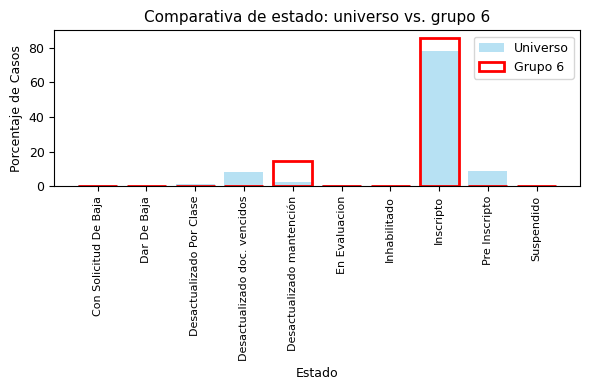

In [81]:
graficar_barras_comparacion(
    df=df,
    columna='Estado',
    condicion_filtrado=lambda df: df['cluster_k10'] == 5,
    titulo='Comparativa de estado: universo vs. grupo 6',
    grupo='Grupo 6'
)

In [51]:
df['provincia'] = df['provincia'].str.replace('Ciudad Autónoma de Buenos Aires', 'CABA', regex=False)
# Convertir la columna 'numero' a string
df['anio_preinscripcion'] = df['anio_preinscripcion'].astype(str)
# Acortar los nombres 
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Persona Física Extranjero No Residente', 'PF Extranjero No Residente', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Persona Jurídica Extranjero Sin Sucursal', 'PJ Extranjero Sin Sucursal', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Sociedad Responsabilidad Limitada', 'S.R.L', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Talleres protegidos de Producción', 'Talleres protegidos', regex=False)
df['Estado'] = df['Estado'].str.replace('Desactualizado Por Documentos Vencidos', 'Desactualizado doc. vencidos', regex=False)
df['Estado'] = df['Estado'].str.replace('Desactualizado Por Mantencion Formulario', 'Desactualizado mantención', regex=False)

In [ ]:
def limpiar_rango(val):
    # Reemplaza todos los números con punto decimal por la parte antes del punto
    matches = re.findall(r'\d+,\d+', val)
  #  return re.sub(r'(\d+)\,\d+', r'\1', val)
    for match in matches:
        # Parte entera antes de la coma
        entero = match.split(',')[0]
        # Agrega punto como separador de miles
        entero_formateado = f"{int(entero):,}".replace(",", ".")
        # Reemplaza el número original con el formateado
        val = val.replace(match, entero_formateado)
    return val


In [1]:
def resumen_por_grupo(df, variable, grupo):

    # Estadísticas por grupo
    resumen = df.groupby(grupo)[variable].agg([
        ('mediana', 'median'),
        ('desvío standard', 'std'),
        ('mínimo', 'min'),
        ('P(25)', lambda x: x.quantile(0.25)),
        ('media', 'mean'),
        ('P(75)', lambda x: x.quantile(0.75)),
        ('máximo', 'max')
    ])

    # Estadísticas del universo (sin aliases personalizados)
    universo = {
        'mediana': df[variable].median(),
        'desvío standard': df[variable].std(),
        'mínimo': df[variable].min(),
        'P(25)': df[variable].quantile(0.25),
        'media': df[variable].mean(),
        'P(75)': df[variable].quantile(0.75),
        'máximo': df[variable].max()
    }

    # Agregar fila 'Universo'
    resumen.loc['Universo'] = universo

    # Reordenar 'Universo' arriba si se desea
    resumen = resumen.loc[['Universo'] + [i for i in resumen.index if i != 'Universo']]

    return resumen

In [39]:
tabla = resumen_por_grupo(df, variable='cant_MontoLimite', grupo='cluster_k10')
print(tabla)

             mediana  desvío standard  mínimo  P(25)     media  P(75)  máximo
cluster_k10                                                                  
Universo         0.0         0.176233     0.0    0.0  0.020147    0.0     6.0
0                0.0         0.000000     0.0    0.0  0.000000    0.0     0.0
1                0.0         0.000000     0.0    0.0  0.000000    0.0     0.0
2                0.0         0.000000     0.0    0.0  0.000000    0.0     0.0
3                0.0         0.000000     0.0    0.0  0.000000    0.0     0.0
4                1.0         0.641586     1.0    1.0  1.266667    1.0     6.0
5                0.0         0.000000     0.0    0.0  0.000000    0.0     0.0
6                0.0         0.176023     0.0    0.0  0.031746    0.0     1.0
7                0.0         0.117034     0.0    0.0  0.013825    0.0     1.0
8                0.0         0.273542     0.0    0.0  0.045455    0.0     2.0
9                0.0         0.090658     0.0    0.0  0.008264  

### Crear perfiles de los grupos

In [11]:
df_perfil = df[['CUIT','Nombre','FechaPreinscripcion','Estado','TipoSocietario','periodo_preinscripcion','anio_preinscripcion','cant_procesos_adjudicado','monto_total_adjudicado','antiguedad','provincia','cant_socios','cant_apercibimientos','cant_suspensiones','cant_antecedentes','cant_Apoderado','cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite','total_articulos_provee','dmonto_total_adjudicado','dcant_procesos_adjudicado','dtotal_articulos_provee','cluster_k10']]

In [13]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 0].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 1", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g1.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|███▏                                                                               | 1/26 [00:00<00:09,  2.52it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 50.71it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 ... 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 1].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 2", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 53.64it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 ... 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 2].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 3", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g3.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|███▏                                                                               | 1/26 [00:00<00:04,  6.14it/s]
%|█████████████████████████████████████████                                         | 13/26 [00:00<00:00, 50.63it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 60.53it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 ... 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 3].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 4", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g4.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|███▏                                                                               | 1/26 [00:00<00:05,  4.63it/s]
%|██████▍                                                                            | 2/26 [00:00<00:03,  6.66it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 41.08it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 ... 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 4].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 5", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g5.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:01, 17.02it/s]
%|████████████▊                                                                      | 4/26 [00:00<00:01, 18.37it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 76.16it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 5].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 6", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g6.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:01, 17.58it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 71.64it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 4 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 6].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 7", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g7.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|█████████▌                                                                         | 3/26 [00:00<00:01, 12.91it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 55.02it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 7].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 8", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g8.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:01, 13.37it/s]
100%|█████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 101.87it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 8].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 9", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g9.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:02, 10.43it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 82.68it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
grupo1 = df_perfil[df_perfil['cluster_k10'] == 9].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kmodes grupo 10", explorative=True)
profile.to_file(ruta+"informe_perfil_kmeans_g10.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/26 [00:00<?, ?it/s]
%|██████▍                                                                            | 2/26 [00:00<00:01, 13.92it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 88.73it/s]
C:\Users\27273398320\AppData\Local\anaconda3\envs\ciencia_datos_py310\lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]